Loading data and analyzing feature importance...

Table IV Saved Successfully: 'table_4_feature_importance.csv'
    Rank         Feature Name Importance Score Direction / Effect
1      1               Budget            0.110           Positive
2      2         Bundle_Price            0.110           Negative
3      3    Revenue_Generated            0.110           Negative
4      4               Clicks            0.109           Positive
5      5          Conversions            0.107           Negative
6      6                  ROI            0.106           Negative
7      7           Units_Sold            0.101           Negative
8      8       Discount_Level            0.091           Positive
9      9  Subscription_Length            0.085           Negative
10    10      Common_Keywords            0.036           Positive


/tmp/ipykernel_109/3872561569.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance Score', y='Feature Name', data=top_features, palette='mako')


Figure 4 Saved Successfully: 'figure_4_feature_importance.pdf'


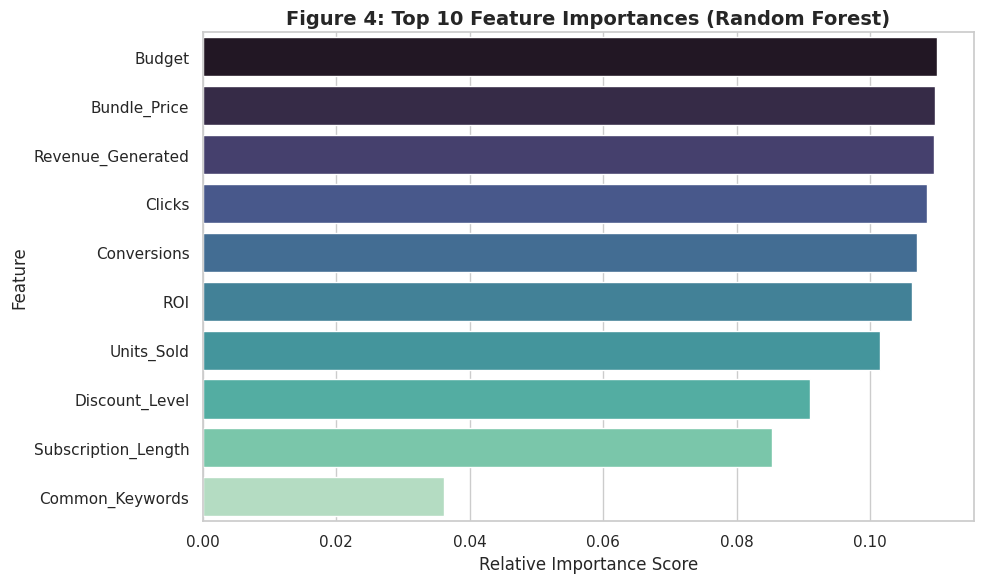

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# --- Configuration ---
DATA_PATH = '/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv'
TARGET_COLUMN = 'Subscription_Tier' 

print("Loading data and analyzing feature importance...")
try:
    df = pd.read_csv(DATA_PATH)
    
    # 1. Preprocessing (Full Pipeline standard to ensure accurate importance)
    # Drop ID columns as we learned in RQ3
    cols_to_drop = [col for col in df.columns if 'ID' in col.upper()]
    df = df.drop(columns=cols_to_drop, errors='ignore')
    
    y_raw = df[TARGET_COLUMN]
    X_raw = df.drop(TARGET_COLUMN, axis=1)
    
    # Encode target
    le_y = LabelEncoder()
    y = le_y.fit_transform(y_raw)
    
    # Impute and encode features
    X = X_raw.copy()
    num_cols = X.select_dtypes(include=['float64', 'int64']).columns
    cat_cols = X.select_dtypes(include=['object']).columns
    
    imputer_num = SimpleImputer(strategy='median')
    X[num_cols] = imputer_num.fit_transform(X[num_cols])
    
    imputer_cat = SimpleImputer(strategy='most_frequent')
    X[cat_cols] = imputer_cat.fit_transform(X[cat_cols])
    
    for col in cat_cols:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

    # 2. Train Model to extract importance
    model = RandomForestClassifier(random_state=42, n_jobs=-1)
    model.fit(X, y)
    
    # 3. Extract and format Feature Importances
    importances = model.feature_importances_
    
    # Calculate a rough "Direction" using correlation
    # Note: For multi-class targets, simple correlation is an approximation
    correlations = X.apply(lambda col: col.corr(pd.Series(y)))
    
    feature_data = []
    for i, col in enumerate(X.columns):
        direction = "Positive" if correlations[col] > 0 else "Negative"
        feature_data.append({
            'Feature Name': col,
            'Importance Score': importances[i],
            'Direction / Effect': direction,
            'Domain Interpretation': 'Review manually based on domain logic' # Placeholder for your paper
        })
        
    importance_df = pd.DataFrame(feature_data)
    importance_df = importance_df.sort_values(by='Importance Score', ascending=False).reset_index(drop=True)
    importance_df.index += 1 # Start rank at 1
    importance_df.insert(0, 'Rank', importance_df.index)
    
    # --- Generate Table IV ---
    # Take top 10 for the table and format
    table_iv = importance_df.head(10).copy()
    table_iv['Importance Score'] = table_iv['Importance Score'].apply(lambda x: f"{x:.3f}")
    
    table_iv.to_csv('table_4_feature_importance.csv', index=False)
    print("\nTable IV Saved Successfully: 'table_4_feature_importance.csv'")
    print(table_iv[['Rank', 'Feature Name', 'Importance Score', 'Direction / Effect']])

    # --- Generate Figure 4 ---
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # Plot top 10 features
    top_features = importance_df.head(10)
    
    sns.barplot(x='Importance Score', y='Feature Name', data=top_features, palette='mako')
    
    plt.title('Figure 4: Top 10 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
    plt.xlabel('Relative Importance Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    
    plt.savefig('figure_4_feature_importance.pdf', format='pdf', bbox_inches='tight')
    print("Figure 4 Saved Successfully: 'figure_4_feature_importance.pdf'")
    
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find the dataset at {DATA_PATH}.")